In [ ]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/TUM/Pratikum/SliceGPTModifications
!pip install -e ".[experiment]"

In [2]:
!pip install -q "peft==0.13.2" "transformers==4.41.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.7/320.7 kB 19.5 MB/s eta 0:00:00


In [1]:
import slicegpt
from slicegpt import rotate, model_utils
print("slicegpt imported:", slicegpt.__file__)
print("rotate imported:", rotate.__file__)
print("model_utils imported:", model_utils.__file__)

slicegpt imported: /content/drive/MyDrive/TUM/Pratikum/SliceGPTModifications/src/slicegpt/__init__.py
rotate imported: /content/drive/MyDrive/TUM/Pratikum/SliceGPTModifications/src/slicegpt/rotate.py
model_utils imported: /content/drive/MyDrive/TUM/Pratikum/SliceGPTModifications/src/slicegpt/model_utils.py


In [2]:
import os

BASE_RESULTS_DIR = "/content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments"
LOG_DIR = os.path.join(BASE_RESULTS_DIR, "logs_opt1.3B")
MODEL_DIR = os.path.join(BASE_RESULTS_DIR, "models_opt1.3B")
BASE_EVAL_DIR = os.path.join(BASE_RESULTS_DIR, "eval")

os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(BASE_EVAL_DIR, exist_ok=True)

In [ ]:
import subprocess
from datetime import datetime

def run_evaluation(dataset, sparsity=0.25):
  log_name = f"eval_{dataset}.txt"
  log_path = os.path.join(LOG_DIR, log_name)

  EVAL_DIR = os.path.join(BASE_EVAL_DIR, f"{dataset}_s{int(sparsity*100)}")
  os.makedirs(EVAL_DIR, exist_ok=True)

  cmd = [
      "python", "experiments/run_lm_eval.py",
      "--model", "facebook/opt-125m",
      "--sliced-model-path", os.path.join(MODEL_DIR, f"{dataset}_s0p25"),
      "--sparsity", str(sparsity), #small fix, now it is gonna be used the argument to decide the sparsity of the model
      "--save-dir", EVAL_DIR,
  ]

  print("\n=====================================================")
  print("Running:", " ".join(cmd))
  print("Log file:", log_path)
  print("Start:", datetime.now())
  print("=====================================================\n")

  with open(log_path, "w") as f:
      process = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
      for line in process.stdout:
          print(line, end="")   # to notebook
          f.write(line)         # to log file

  ret = process.wait()
  print("\nFinished with return code:", ret)
  print("End:", datetime.now())

In [ ]:
#in the previous run evaluation code there are the following issues:
'''
--sliced-model-path is hard-coded to .../{dataset}_s0p25
→ even if you call run_evaluation(dataset, sparsity=0.5), it still loads the 25% model.

Log name doesn’t include sparsity
→ if you evaluate multiple sparsities for the same dataset, logs will overwrite each other.

Eval dir name uses s{int(sparsity*100)} while model dir uses s0pXX in other parts of your project (like wikitext2_s0p00). Better to use a consistent tag.

'''

In [ ]:
#Fixed run evaluation function
import subprocess
from datetime import datetime

def run_evaluation(dataset, sparsity=0.25):
    # Build a consistent tag for sparsity, e.g.
    #  0.00 -> "s0p00"
    #  0.25 -> "s0p25"
    #  0.50 -> "s0p50"
    sparsity_pct = int(sparsity * 100)
    sparsity_tag = f"s0p{sparsity_pct:02d}"

    # Log file name includes dataset + sparsity
    log_name = f"eval_{dataset}_{sparsity_tag}.txt"
    log_path = os.path.join(LOG_DIR, log_name)

    # Evaluation results directory:
    #   /.../SliceGPTExperiments/eval/{dataset}_s0p25
    EVAL_DIR = os.path.join(BASE_EVAL_DIR, f"{dataset}_{sparsity_tag}")
    os.makedirs(EVAL_DIR, exist_ok=True)

    # Sliced model path:
    #   /.../SliceGPTExperiments/models/{dataset}_s0p25
    sliced_model_path = os.path.join(MODEL_DIR, f"{dataset}_{sparsity_tag}")

    cmd = [
        "python", "experiments/run_lm_eval.py",
        "--model", "facebook/opt-125m",
        "--sliced-model-path", sliced_model_path,
        "--sparsity", str(sparsity),
        "--save-dir", EVAL_DIR,
        # you can later add: "--tasks", "squad" etc. here if needed
    ]

    print("\n=====================================================")
    print("Running:", " ".join(cmd))
    print("Log file:", log_path)
    print("Start:", datetime.now())
    print("=====================================================\n")

    with open(log_path, "w") as f:
        process = subprocess.Popen(
            cmd,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
        )
        for line in process.stdout:
            print(line, end="")  # to notebook
            f.write(line)        # to log file

    ret = process.wait()
    print("\nFinished with return code:", ret)
    print("End:", datetime.now())


In [ ]:
# run_evaluation("wikitext2")

In [3]:
import logging
import sys

# Get the root logger or a named logger
logger = logging.getLogger()
logger.setLevel(logging.INFO)  # allow INFO and above

for h in list(logger.handlers):
  logger.removeHandler(h)

# Create a handler that writes to stdout
handler = logging.StreamHandler(sys.stdout)
handler.setLevel(logging.INFO)

# (Optional) set a formatting for readability
formatter = logging.Formatter('%(levelname)s - %(message)s')
handler.setFormatter(formatter)

# Add handler to the logger
logger.addHandler(handler)

# Now test
logger.info("This will be printed to stdout")
logger.debug("This will not print (level is INFO)")

INFO - This will be printed to stdout


In [ ]:
from lm_eval.tasks import initialize_tasks
initialize_tasks()

In [ ]:
import json

import lm_eval
# import torch
from lm_eval import tasks
from lm_eval import utils as lm_eval_utils
from lm_eval.api.registry import ALL_TASKS
from lm_eval.models.huggingface import HFLM
from lm_eval.tasks import initialize_tasks

from slicegpt import gpu_utils, hf_utils, utils
from slicegpt.config import config

logging.basicConfig(
    level=logging.DEBUG,
    stream=sys.stdout,
    format="%(levelname)s: %(message)s"
)

def eval(args):
  # based on slicegpt's run_lm_eval.py

  logger.info("Running Evaluation")

  logger.info(f"Loading sliced {args["model"]} from {args["sliced_model_path"]} with sparsity {args["sparsity"]}")
  model_adapter, tokenizer = hf_utils.load_sliced_model(
    args["model"],
    args["sliced_model_path"],
    sparsity=args["sparsity"],
    # token=args.hf_token,
    token=None,
    round_interval=args["round_interval"],
  )

  # the lm eval harness ties the weights, but this should not be done for sliced models unless the lm_head was sliced
  model_adapter.model.tie_weights = lambda: None

  model_adapter.model.to(config.device)

  hflm = HFLM(pretrained=model_adapter.model, tokenizer=tokenizer, batch_size=args["batch_size"])

  if args["tasks"] is None:
    task_names = tasks.ALL_TASKS
  else:
    task_names = lm_eval_utils.pattern_match(args["tasks"], ALL_TASKS)

  logger.info(f"Selected Tasks: {task_names}")

  results = lm_eval.simple_evaluate(hflm,
                                    tasks=task_names,
                                    num_fewshot=args["num_fewshot"],
                                    batch_size=args["batch_size"],
                                    limit=args["limit"],
                                    write_out=True,
                                    log_samples=True)

  logger.info("Results:")
  logger.info(results)

  model_name = args["model"].replace("/", "-")
  with open(f"{args["save_dir"]}/results_s{sparsity:.2f}_{"_".join(task_names)}.json", "w") as f:
    json.dump(results, f)

  return results



In [ ]:
#fixed eval cell
import os
import sys
import json
import logging

import lm_eval
from lm_eval import tasks
from lm_eval import utils as lm_eval_utils
from lm_eval.api.registry import ALL_TASKS
from lm_eval.models.huggingface import HFLM

from slicegpt import gpu_utils, hf_utils, utils
from slicegpt.config import config

# Do NOT reconfigure logging here if you've already done it in a previous cell.
# We just reuse the existing logger.
logger = logging.getLogger(__name__)


def eval(args):
    """
    Run LM Evaluation Harness on a sliced (pruned) model.

    Expected args (dict-like):
      - "model": HF model name, e.g. "facebook/opt-125m"
      - "sliced_model_path": path to sliced checkpoint dir
      - "sparsity": float, e.g. 0.25
      - "round_interval": int or None (optional)
      - "batch_size": int
      - "tasks": None, string (comma-separated) or list of patterns
      - "num_fewshot": int
      - "limit": int or None
      - "save_dir": output directory for results
    """

    logger.info("Running Evaluation")

    # --- Load sliced model ---
    logger.info(
        f"Loading sliced {args['model']} from {args['sliced_model_path']} "
        f"with sparsity {args['sparsity']}"
    )

    model_adapter, tokenizer = hf_utils.load_sliced_model(
        args["model"],
        args["sliced_model_path"],
        sparsity=args["sparsity"],
        token=None,
        round_interval=args.get("round_interval", None),
    )

    # The lm-eval harness normally ties weights; we disable this for sliced models
    if hasattr(model_adapter.model, "tie_weights"):
        model_adapter.model.tie_weights = lambda *x, **kw: None

    model_adapter.model.to(config.device)

    # Wrap in LM Evaluation Harness HF adapter
    hflm = HFLM(
        pretrained=model_adapter.model,
        tokenizer=tokenizer,
        batch_size=args["batch_size"],
    )

    # --- Task selection ---
    if args["tasks"] is None:
        # Using ALL_TASKS is usually too heavy for Colab; you can change this to raise if you prefer.
        logger.warning(
            "args['tasks'] is None -> using ALL_TASKS. "
            "This may be very slow / memory-heavy."
        )
        task_names = tasks.ALL_TASKS
    else:
        # Accept either a comma-separated string or a list
        if isinstance(args["tasks"], str):
            patterns = [t.strip() for t in args["tasks"].split(",") if t.strip()]
        else:
            patterns = args["tasks"]
        task_names = lm_eval_utils.pattern_match(patterns, ALL_TASKS)

    logger.info(f"Selected Tasks: {task_names}")

    # --- Run evaluation ---
    results = lm_eval.simple_evaluate(
        hflm,
        tasks=task_names,
        num_fewshot=args["num_fewshot"],
        batch_size=args["batch_size"],
        limit=args["limit"],
        write_out=False,
        log_samples=False,
    )

    results = results["results"]
    #logger.info("Results:")
    #logger.info(results)

    # --- Save results ---
    os.makedirs(args["save_dir"], exist_ok=True)

    sparsity_tag = f"{args['sparsity']:.2f}"  # e.g. "0.25"
    # Optional: sanitize model name if you want to include it
    # model_name = args["model"].replace("/", "-")

    result_path = os.path.join(
        args["save_dir"],
        f"results_s{sparsity_tag}_{'_'.join(task_names)}.json",
    )

    with open(result_path, "w") as f:
        json.dump(results, f, indent=2)

    logger.info(f"Saved results to {result_path}")

    return results


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
!pip uninstall -y lm-eval lm_eval
!pip install "lm-eval==0.4.2"

In [ ]:
#new cell for eval
import os, json, logging
import lm_eval
from lm_eval import utils as lm_eval_utils
from lm_eval.models.huggingface import HFLM
from lm_eval.tasks import TaskManager

from slicegpt import hf_utils
from slicegpt.config import config

logger = logging.getLogger(__name__)

def eval(args):
    logger.info("Running Evaluation")
    logger.info(
        f"Loading sliced {args['model']} from {args['sliced_model_path']} "
        f"with sparsity {args['sparsity']}"
    )

    model_adapter, tokenizer = hf_utils.load_sliced_model(
        args["model"],
        args["sliced_model_path"],
        sparsity=args["sparsity"],
        token=None,
        round_interval=args.get("round_interval", None),
    )

    if hasattr(model_adapter.model, "tie_weights"):
        model_adapter.model.tie_weights = lambda *x, **kw: None

    model_adapter.model.to(config.device)

    hflm = HFLM(
        pretrained=model_adapter.model,
        tokenizer=tokenizer,
        batch_size=args["batch_size"],
    )

    # ---- Task selection (TaskManager is the source of truth) ----
    tm = args.get("task_manager") or TaskManager()
    all_task_names = list(tm.all_tasks) if isinstance(tm.all_tasks, list) else list(tm.all_tasks.keys())

    if args["tasks"] is None:
        task_names = sorted(all_task_names)
    else:
        patterns = (
            [t.strip() for t in args["tasks"].split(",") if t.strip()]
            if isinstance(args["tasks"], str)
            else list(args["tasks"])
        )
        task_names = lm_eval_utils.pattern_match(patterns, all_task_names)

    logger.info(f"Selected Tasks: {task_names}")

    results = lm_eval.simple_evaluate(
        model=hflm,
        tasks=task_names,
        task_manager=tm,
        num_fewshot=args["num_fewshot"],
        batch_size=args["batch_size"],
        limit=args["limit"],
        write_out=False,
        log_samples=False,
    )["results"]

    os.makedirs(args["save_dir"], exist_ok=True)
    sparsity_tag = f"{args['sparsity']:.2f}"
    out_path = os.path.join(args["save_dir"], f"results_s{sparsity_tag}_{'_'.join(task_names)}.json")
    with open(out_path, "w") as f:
        json.dump(results, f, indent=2)

    logger.info(f"Saved results to {out_path}")
    return results


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
tasks.ALL_TASKS

In [ ]:
args = {
    "model": "facebook/opt-1.3B",
    "sliced_model_path": os.path.join(MODEL_DIR, "wikitext2_s0p25"),
    "sparsity": 0.25,
    "save-dir": os.path.join(BASE_EVAL_DIR, "wikitext2_s25"),
    "tasks": ["squadv2"],
    "num_fewshot": 0,
    "batch_size": 64,
    "round_interval": 8,
    "limit": None
}
eval(args)

INFO - Running Evaluation
INFO - Loading sliced facebook/opt-125m from /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/models_opt125M/wikitext2_s0p25 with sparsity 0.25
INFO - Loading facebook/opt-125m config  from Hugging Face


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


INFO - Loading model done
INFO - Replacing layers
INFO - Replacing layers done
INFO - Fusing layernorm modules
INFO - Fusing layernorm modules done
INFO - Loading sliced model weights from /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/models_opt125M/wikitext2_s0p25
WARNING - `pretrained` model kwarg is not of type `str`. Many other model arguments may be ignored. Please do not launch via accelerate or use `parallelize=True` if passing an existing model this way.
WARNING - Passed an already-initialized model through `pretrained`, assuming single-process call to evaluate() or custom distributed integration
INFO - Selected Tasks: ['squadv2']


Generating train split:   0%|          | 0/130319 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/11873 [00:00<?, ? examples/s]

INFO - Building contexts for task on rank 0...
INFO - Running generate_until requests


  0%|          | 0/11873 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
!lm_eval --tasks list | grep -i coqa


In [ ]:
model = "facebook/opt-125m"
model_name = model.replace("/", "-")
datasets = ['hotpotqa']
sparsities = [0.0, 0.10, 0.25, 0.40, 0.60]
#sparsities = [0.25, 0.40, 0.60] #what is missing to do tmw

dir_prefix = "squadEval"

MODEL_DIR = os.path.join(BASE_RESULTS_DIR, "models_opt125M")

results = None

for dataset in datasets:
  for sparsity in sparsities:
    EVAL_DIR = os.path.join(
    BASE_EVAL_DIR,
    dir_prefix,
    f"{model_name}_{dataset}"
    )
    os.makedirs(EVAL_DIR, exist_ok=True)

    args = {
        "model": model,
        "sliced_model_path": os.path.join(MODEL_DIR, f"{dataset}_s{sparsity:.2f}".replace(".", "p")),
        "sparsity": sparsity,
        "save_dir": EVAL_DIR,
        "tasks": ["squadv2","coqa"],
        "num_fewshot": 0,
        "batch_size": 64,
        "round_interval": 8,
        "limit": None
    }

    results = eval(args)

INFO - Running Evaluation
INFO - Loading sliced facebook/opt-125m from /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/models_opt125M/hotpotqa_s0p00 with sparsity 0.0
INFO - Loading facebook/opt-125m config  from Hugging Face


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/651 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

INFO - Running generate_until requests



Running generate_until requests: 100%|██████████| 12373/12373 [18:03<00:00, 11.42it/s]

INFO - Running loglikelihood requests



Running loglikelihood requests: 100%|██████████| 11873/11873 [00:09<00:00, 1213.23it/s]
/usr/local/lib/python3.12/dist-packages/datasets/load.py:756: FutureWarning: The repository for squad_v2 contains custom code which must be executed to correctly load the metric. You can inspect the repository content at https://raw.githubusercontent.com/huggingface/datasets/2.18.0/metrics/squad_v2/squad_v2.py
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this metric from the next major release of `datasets`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/datasets/load.py:756: FutureWarning: The repository for squad_v2 contains custom code which must be executed to correctly load the metric. You can inspect the repository content at https://raw.githubusercontent.com/huggingface/datasets/2.18.0/metrics/squad_v2/squad_v2.py
You can avoid this message in future by passing the argument `trust_r

INFO - Saved results to /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/eval/squadEval/facebook-opt-125m_hotpotqa/results_s0.60_coqa_squadv2.json


In [ ]:
#new cell for eval
from lm_eval import evaluator
from lm_eval.tasks import TaskManager
model = "facebook/opt-125m"
model_name = model.replace("/", "-")
datasets = ['coqa']
sparsities = [0.0, 0.10, 0.25, 0.40, 0.60]
#sparsities = [0.0]

dir_prefix = "squadEval"

MODEL_DIR = os.path.join(BASE_RESULTS_DIR, "models_opt125M")

results = None
tm = TaskManager()

for dataset in datasets:
  for sparsity in sparsities:
    EVAL_DIR = os.path.join(
    BASE_EVAL_DIR,
    dir_prefix,
    f"{model_name}_{dataset}"
    )
    os.makedirs(EVAL_DIR, exist_ok=True)

    args = {
        "model": model,
        "sliced_model_path": os.path.join(MODEL_DIR, f"{dataset}_s{sparsity:.2f}".replace(".", "p")),
        "sparsity": sparsity,
        "save_dir": EVAL_DIR,
        "tasks": ["squadv2"],
        "num_fewshot": 0,
        "batch_size": 64,
        "round_interval": 8,
        "limit": None,
        "task_manager": tm,
    }

    results = eval(args)

INFO - Running Evaluation
INFO - Loading sliced facebook/opt-1.3B from /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/models_opt1.3B/coqa_s0p00 with sparsity 0.0
INFO - Loading facebook/opt-1.3B config  from Hugging Face
INFO - Loading model done
INFO - Replacing layers
INFO - Replacing layers done
INFO - Fusing layernorm modules
INFO - Fusing layernorm modules done
INFO - Loading sliced model weights from /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/models_opt1.3B/coqa_s0p00/opt-1.3B_0.0.pt
WARNING - `pretrained` model kwarg is not of type `str`. Many other model arguments may be ignored. Please do not launch via accelerate or use `parallelize=True` if passing an existing model this way.
WARNING - Passed an already-initialized model through `pretrained`, assuming single-process call to evaluate() or custom distributed integration
INFO - Selected Tasks: ['squadv2']
INFO - Setting random seed to 0 | Setting numpy seed to 1234 | Setting torch manual seed to 1234
WARNI


100%|██████████| 11873/11873 [00:00<00:00, 148913.24it/s]

INFO - Running generate_until requests




Running generate_until requests:   0%|          | 0/11873 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 2.62 GiB. GPU 0 has a total capacity of 22.03 GiB of which 1.43 GiB is free. Including non-PyTorch memory, this process has 20.60 GiB memory in use. Of the allocated memory 17.92 GiB is allocated by PyTorch, and 2.45 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
print(json.dumps(results["samples"]["arc_easy"], indent=1))

In [ ]:
sample = results["samples"]["squadv2"][1]

In [ ]:
# print(json.dumps(results, indent=1))
# print([key for key in results["samples"]["squadv2"][0]])
# print(json.dumps(results["samples"]["squadv2"][0], indent=1))

# print(json.dumps(sample0, indent = 1))
print(sample["arguments"][0][0])

In [ ]:
print(json.dumps(sample, indent = 1))

In [ ]:
from datasets import load_metric

metric = load_metric("squad_v2")

pred = sample["exact"][0]
ref = sample["exact"][1]

scores = metric.compute(
    predictions=[pred],
    references=[ref]
)

print(scores)

In [ ]:
model = "facebook/opt-125m"
model_name = model.replace("/", "-")
dataset = 'squad'
BASE_EVAL_DIR = os.path.join(
    BASE_EVAL_DIR,
    "evals_week4"
    )
EVAL_DIR

'/content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/eval/eval_weeks4/facebook-opt-125m_squad'

In [ ]:
BASE_EVAL_DIR

'/content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/eval/evals_week4'

In [ ]:
!pip install json

ERROR: Could not find a version that satisfies the requirement json (from versions: none)
ERROR: No matching distribution found for json


In [ ]:
import pandas as pd

def load_results(model, dataset, task_names, task):
  sparsities = [0.00, 0.10, 0.25, 0.40, 0.60]

  rows = []

  for sparsity in sparsities:
    RESULTS_DIR = os.path.join(BASE_EVAL_DIR, f"{model.replace("/", "-")}_{dataset}")
    FILE_NAME = f"results_s{sparsity:.2f}_{"_".join(task_names)}.json"
    path = os.path.join(RESULTS_DIR, FILE_NAME)

    with open(path, "r") as f:
      data = json.load(f)

    metrics = data[task]

    row = {"sparsity": sparsity}
    for key, value in metrics.items():
      if isinstance(value, (int, float)):
        row[key] = value

    rows.append(row)

  df = pd.DataFrame(rows)

  return df

In [ ]:
import matplotlib.pyplot as plt


def plot_metric(df, metric, metric_title, model_identifier):
  plt.plot(df["sparsity"], df[metric], marker="o")
  plt.title(f"{metric_title} vs Sparsity ({model_identifier})")
  plt.xlabel("Sparsity")
  plt.ylabel(metric_title)
  plt.legend()
  plt.grid(True)

  ax = plt.gca()
  ax.set_ylim([0.0, 1.0])

  plt.show()


/tmp/ipython-input-3329772220.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


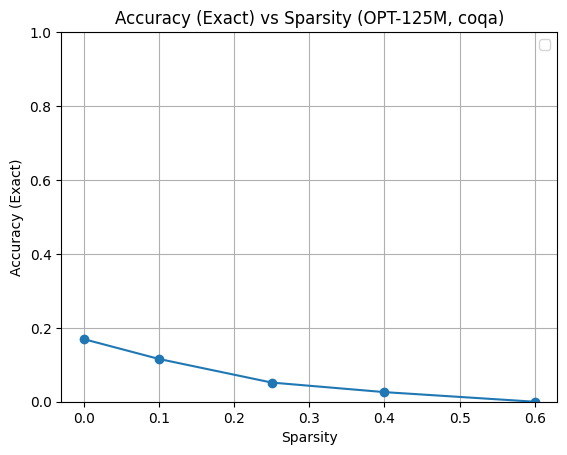

In [ ]:
import json
result_df = load_results("facebook/opt-125m", "squad", ["coqa"], "coqa")
plot_metric(result_df, "em,none", "Accuracy (Exact)", "OPT-125M, coqa")

/tmp/ipython-input-3329772220.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


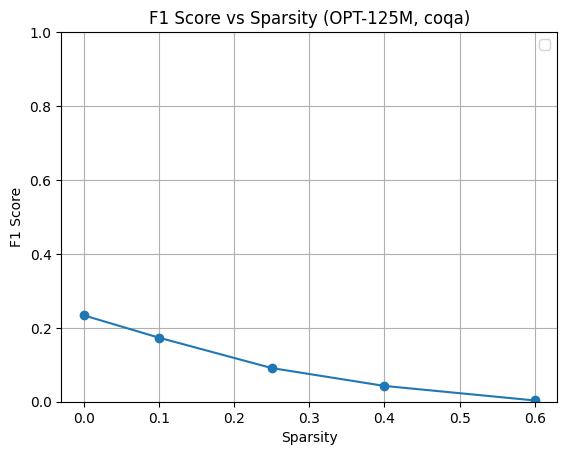

In [ ]:
plot_metric(result_df, "f1,none", "F1 Score", "OPT-125M, coqa")

In [ ]:
result_df

,sparsity,"exact,none","f1,none","HasAns_exact,none","HasAns_f1,none","NoAns_exact,none","NoAns_f1,none","best_exact,none","best_f1,none"
0,0.00,0.530616,2.873236,0.826586,5.518545,0.235492,0.235492,50.071591,50.071591
1,0.10,1.313905,3.237856,0.151822,4.005241,2.472666,2.472666,50.071591,50.071857
2,0.25,7.824476,9.233190,0.016869,2.838337,15.609756,15.609756,50.071591,50.071789
3,0.40,44.664365,44.848671,0.000000,0.369142,89.201009,89.201009,50.071591,50.071591
4,0.60,30.666217,30.907045,0.000000,0.482346,61.244743,61.244743,50.071591,50.071591


In [ ]:
# model_adapter, tokenizer = hf_utils.get_model_and_tokenizer("facebook/opt-125m", None, token=None)

model_adapter, tokenizer = hf_utils.load_sliced_model(
            "facebook/opt-1.3b",
            os.path.join(MODEL_DIR, "wikitext2_s0p00"),
            sparsity=0.0,
            token=None,
            round_interval=8,
        )

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

model = AutoModelForCausalLM.from_pretrained("facebook/opt-1.3b").to(config.device)
tokenizer = AutoTokenizer.from_pretrained("facebook/opt-1.3b")

In [ ]:
import torch

model = model_adapter.model
model.to("cuda")

In [ ]:
def predict(prompt):
  inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

  with torch.no_grad():
    output_ids = model.generate(
        **inputs,
        max_new_tokens=64,
        do_sample=False,
        eos_token_id=tokenizer.eos_token_id,
    )

  return tokenizer.decode(output_ids[0], skip_special_tokens=True)

In [ ]:
def predict_split_newline(prompt):
  inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

  with torch.no_grad():
    output_ids = model.generate(
        **inputs,
        max_new_tokens=64,
        do_sample=False,
        eos_token_id=tokenizer.eos_token_id,
    )[:, inputs.input_ids.shape[1]:]

  answer = tokenizer.decode(output_ids[0], skip_special_tokens=True).split("\n")[0]
  return prompt + answer

In [ ]:
prompt = "Question: What is the Capital of Germany?\nAnswer:"
print(predict(prompt))

In [ ]:
prompt = sample["arguments"][0][0]

print(predict_split_newline(prompt))

In [ ]:
prompt = f"What is 2 + 2?"

print(predict(prompt))

In [4]:
import re
import string

ARTICLES_REGEX = re.compile(r"\b(a|an|the)\b", re.UNICODE)

def normalize_answer(s):
    """Lower text and remove punctuation, articles and extra whitespace."""

    def remove_articles(text):
        return ARTICLES_REGEX.sub(" ", text)

    def white_space_fix(text):
        return " ".join(text.split())

    def remove_punc(text):
        exclude = set(string.punctuation)
        return "".join(ch for ch in text if ch not in exclude)

    def lower(text):
        return text.lower()

    return white_space_fix(remove_articles(remove_punc(lower(s))))

In [ ]:
def token_f1(pred: str, truth: str, tokenizer) -> float:
    pred_tokens = normalize_answer(pred).split()
    truth_tokens = normalize_answer(truth).split()

    from collections import Counter
    pred_counts = Counter(pred_tokens)
    truth_counts = Counter(truth_tokens)

    overlap = sum(min(pred_counts[t], truth_counts[t]) for t in truth_counts)

    precision = overlap / len(pred_tokens) if pred_tokens else 0
    recall = overlap / len(truth_tokens) if truth_tokens else 0
    return 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0

In [ ]:
token_f1(sample["exact"][1]["answers"]["text"][1], sample["exact"][0]["prediction_text"], tokenizer)

In [ ]:
#next cells are for hotpot eval

In [5]:
import os, json, torch, re, string
from tqdm import tqdm
from collections import Counter
from slicegpt import hf_utils

def build_context(example):
    paragraphs = []
    for paragraph_title, sentences in example["context"]:
        paragraphs.append(f"[{paragraph_title}] " + " ".join(sentences))
    return "\n".join(paragraphs)

def get_max_input_len(tokenizer, model):
    tmax = getattr(tokenizer, "model_max_length", None)
    if tmax and tmax < 10**6:
        return int(tmax)
    mmax = getattr(model.config, "max_position_embeddings", None)
    if mmax:
        return int(mmax)
    return 2048


In [6]:
import os, json, torch, gc
from tqdm import tqdm
from slicegpt import hf_utils

@torch.inference_mode()
def generate_hotpot_predictions_sliced_batched(
    model_name: str,
    sliced_model_path: str,
    sparsity: float,
    hotpot_path: str,
    out_path: str,
    limit: int | None = None,
    max_new_tokens: int = 64,
    batch_size: int = 2,          # start small for Hotpot
    round_interval: int | None = None,
    overwrite: bool = False,
    verbose: bool = True,
):
    if (not overwrite) and os.path.exists(out_path):
        if verbose:
            print(f"[cache] Using existing predictions: {out_path}")
        return out_path

    model_adapter, tokenizer = hf_utils.load_sliced_model(
        model_name,
        sliced_model_path,
        sparsity=sparsity,
        token=None,
        round_interval=round_interval,
    )
    model = model_adapter.model.cuda().eval()

    # --- decoder-only models should use LEFT padding
    tokenizer.padding_side = "left"

    # pad/eos handling
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token
    pad_id = tokenizer.pad_token_id
    eos_id = tokenizer.eos_token_id

    vocab = int(model.config.vocab_size)
    if pad_id is None or pad_id >= vocab:
        raise ValueError(f"Bad pad_token_id={pad_id} for vocab_size={vocab}")

    max_inp = get_max_input_len(tokenizer, model)  # OPT should be 2048

    # IMPORTANT: leave room for generation
    max_prompt_len = max(1, max_inp - max_new_tokens)

    with open(hotpot_path, "r", encoding="utf-8") as f:
        examples = json.load(f)

    if limit is None:
        limit = len(examples)
    limit = min(limit, len(examples))

    predictions = {"answer": {}, "sp": {}}

    for start in tqdm(range(0, limit, batch_size), desc=f"Hotpot batched gen (s={sparsity})"):
        batch = examples[start : start + batch_size]
        batch_ids, batch_prompts = [], []

        for ex in batch:
            qid = ex["_id"]
            question = ex["question"]
            context_text = build_context(ex)
            prompt = (
                "Answer the question using the context. Reply only with a short answer.\n\n"
                f"Context:\n{context_text}\n\n"
                f"Question: {question}\n"
                "Answer:"
            )
            batch_ids.append(qid)
            batch_prompts.append(prompt)

        inputs = tokenizer(
            batch_prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_prompt_len,   # <-- key fix
        ).to(model.device)

        # sanity check (catch embedding OOB early)
        max_id = int(inputs["input_ids"].max().item())
        min_id = int(inputs["input_ids"].min().item())
        if max_id >= vocab or min_id < 0:
            raise ValueError(f"Token id out of range: min={min_id}, max={max_id}, vocab_size={vocab}")

        gen = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            num_beams=1,
            eos_token_id=eos_id,
            pad_token_id=pad_id,
            use_cache=True,
        )

        # with left padding, this is still correct:
        input_lengths = inputs["attention_mask"].sum(dim=1).tolist()

        for i, qid in enumerate(batch_ids):
            continuation_ids = gen[i][input_lengths[i]:]
            completion = tokenizer.decode(continuation_ids, skip_special_tokens=True).strip()
            predictions["answer"][qid] = completion.splitlines()[0].strip() if completion else ""
            predictions["sp"][qid] = []

    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(predictions, f)

    # cleanup
    del model
    del model_adapter
    torch.cuda.empty_cache()
    gc.collect()

    if verbose:
        print(f"[ok] Saved predictions: {out_path}")
    return out_path

In [7]:
def normalize_answer(s):
    def remove_articles(text):
        return re.sub(r"\b(a|an|the)\b", " ", text)
    def white_space_fix(text):
        return " ".join(text.split())
    def remove_punc(text):
        exclude = set(string.punctuation)
        return "".join(ch for ch in text if ch not in exclude)
    def lower(text):
        return text.lower()
    return white_space_fix(remove_articles(remove_punc(lower(s))))

def f1_score(prediction, ground_truth):
    normalized_prediction = normalize_answer(prediction)
    normalized_ground_truth = normalize_answer(ground_truth)

    ZERO_METRIC = (0, 0, 0)

    if normalized_prediction in ["yes", "no", "noanswer"] and normalized_prediction != normalized_ground_truth:
        return ZERO_METRIC
    if normalized_ground_truth in ["yes", "no", "noanswer"] and normalized_prediction != normalized_ground_truth:
        return ZERO_METRIC

    prediction_tokens = normalized_prediction.split()
    ground_truth_tokens = normalized_ground_truth.split()
    common = Counter(prediction_tokens) & Counter(ground_truth_tokens)
    num_same = sum(common.values())
    if num_same == 0:
        return ZERO_METRIC

    precision = 1.0 * num_same / len(prediction_tokens)
    recall = 1.0 * num_same / len(ground_truth_tokens)
    f1 = (2 * precision * recall) / (precision + recall)
    return f1, precision, recall

def exact_match_score(prediction, ground_truth):
    return normalize_answer(prediction) == normalize_answer(ground_truth)

def update_answer(metrics, prediction, gold):
    em = exact_match_score(prediction, gold)
    f1, prec, recall = f1_score(prediction, gold)
    metrics["em"] += float(em)
    metrics["f1"] += f1
    metrics["prec"] += prec
    metrics["recall"] += recall
    return em, prec, recall

def update_sp(metrics, prediction, gold):
    cur_sp_pred = set(map(tuple, prediction))
    gold_sp_pred = set(map(tuple, gold))

    tp = sum(1 for e in cur_sp_pred if e in gold_sp_pred)
    fp = sum(1 for e in cur_sp_pred if e not in gold_sp_pred)
    fn = sum(1 for e in gold_sp_pred if e not in cur_sp_pred)

    prec = 1.0 * tp / (tp + fp) if tp + fp > 0 else 0.0
    recall = 1.0 * tp / (tp + fn) if tp + fn > 0 else 0.0
    f1 = 2 * prec * recall / (prec + recall) if prec + recall > 0 else 0.0
    em = 1.0 if fp + fn == 0 else 0.0

    metrics["sp_em"] += em
    metrics["sp_f1"] += f1
    metrics["sp_prec"] += prec
    metrics["sp_recall"] += recall
    return em, prec, recall

def hotpot_eval(prediction_file, gold_file):
    with open(prediction_file, "r", encoding="utf-8") as f:
        prediction = json.load(f)
    with open(gold_file, "r", encoding="utf-8") as f:
        gold = json.load(f)

    metrics = {
        "em": 0, "f1": 0, "prec": 0, "recall": 0,
        "sp_em": 0, "sp_f1": 0, "sp_prec": 0, "sp_recall": 0,
        "joint_em": 0, "joint_f1": 0, "joint_prec": 0, "joint_recall": 0,
    }

    for dp in gold:
        cur_id = dp["_id"]
        can_eval_joint = True

        if cur_id not in prediction["answer"]:
            print(f"missing answer {cur_id}")
            can_eval_joint = False
        else:
            em, prec, recall = update_answer(metrics, prediction["answer"][cur_id], dp["answer"])

        if cur_id not in prediction["sp"]:
            print(f"missing sp fact {cur_id}")
            can_eval_joint = False
        else:
            sp_em, sp_prec, sp_recall = update_sp(metrics, prediction["sp"][cur_id], dp["supporting_facts"])

        if can_eval_joint:
            joint_prec = prec * sp_prec
            joint_recall = recall * sp_recall
            joint_f1 = (2 * joint_prec * joint_recall / (joint_prec + joint_recall)) if (joint_prec + joint_recall) > 0 else 0.0
            joint_em = em * sp_em

            metrics["joint_em"] += joint_em
            metrics["joint_f1"] += joint_f1
            metrics["joint_prec"] += joint_prec
            metrics["joint_recall"] += joint_recall

    N = len(gold)
    for k in list(metrics.keys()):
        metrics[k] /= N

    return metrics


In [ ]:
import os, json

model_hf = "facebook/opt-125m"
model_tag = model_hf.replace("/", "-")

sparsities = [0.0, 0.10, 0.25, 0.40, 0.60]
datasets = ["squad", "wikitext2", "hotpotqa", "coqa"]

dir_prefix = "squadEval"

# adjust these to your setup
MODEL_DIR = os.path.join(BASE_RESULTS_DIR, "models_opt125M")
hotpot_path = "/content/drive/MyDrive/TUM/Pratikum/code/sliced_rag/data/hotpot_dev_distractor_v1.json"

limit = None           # None for full
max_new_tokens = 64
round_interval = 8
batch_size = 64

all_results = []

for dataset in datasets:
    for sparsity in sparsities:
        EVAL_DIR = os.path.join(BASE_EVAL_DIR, dir_prefix, f"{model_tag}_{dataset}")
        os.makedirs(EVAL_DIR, exist_ok=True)

        sliced_model_path = os.path.join(
            MODEL_DIR,
            f"{dataset}_s{sparsity:.2f}".replace(".", "p")
        )

        sparsity_tag = f"{sparsity:.2f}".replace(".", "p")
        pred_path = os.path.join(EVAL_DIR, f"hotpot_predictions_s{sparsity_tag}.json")

        # 1) generate (batched + cached)
        pred_path = generate_hotpot_predictions_sliced_batched(
            model_name=model_hf,
            sliced_model_path=sliced_model_path,
            sparsity=sparsity,
            hotpot_path=hotpot_path,
            out_path=pred_path,
            limit=limit,
            max_new_tokens=max_new_tokens,
            batch_size=batch_size,
            round_interval=round_interval,
            overwrite=False,
            verbose=True,
        )

        # 2) evaluate
        metrics = hotpot_eval(pred_path, hotpot_path)

        # 3) save metrics
        out_metrics_path = os.path.join(EVAL_DIR, f"results_s{sparsity_tag}_hotpot.json")
        payload = {
            "model": model_tag,
            "model_hf": model_hf,
            "calibration_dataset": dataset,
            "sparsity": sparsity,
            "sliced_model_path": sliced_model_path,
            "predictions_path": pred_path,
            "hotpot_gold_path": hotpot_path,
            "limit": limit,
            "max_new_tokens": max_new_tokens,
            "batch_size": batch_size,
            "round_interval": round_interval,
            "notes": "Answer-only HotpotQA eval (sp empty => sp/joint ~ 0 by design).",
            "metrics": metrics,
        }
        with open(out_metrics_path, "w", encoding="utf-8") as f:
            json.dump(payload, f, indent=2)

        all_results.append({"calib_dataset": dataset, "sparsity": sparsity, **metrics})

print("Done. Collected results:")
for r in all_results:
    print(r)

Hotpot batched gen (s=0.0): 100%|██████████| 116/116 [05:16<00:00,  2.73s/it]


[ok] Saved predictions: /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/eval/squadEval/facebook-opt-125m_squad/hotpot_predictions_s0p00.json


Hotpot batched gen (s=0.1): 100%|██████████| 116/116 [05:16<00:00,  2.73s/it]


[ok] Saved predictions: /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/eval/squadEval/facebook-opt-125m_squad/hotpot_predictions_s0p10.json


Hotpot batched gen (s=0.25): 100%|██████████| 116/116 [05:13<00:00,  2.70s/it]


...

[ok] Saved predictions: /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/eval/squadEval/facebook-opt-125m_coqa/hotpot_predictions_s0p25.json


Hotpot batched gen (s=0.4): 100%|██████████| 116/116 [05:13<00:00,  2.70s/it]


[ok] Saved predictions: /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/eval/squadEval/facebook-opt-125m_coqa/hotpot_predictions_s0p40.json


Hotpot batched gen (s=0.6): 100%|██████████| 116/116 [05:10<00:00,  2.68s/it]


[ok] Saved predictions: /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/eval/squadEval/facebook-opt-125m_coqa/hotpot_predictions_s0p60.json
Done. Collected results:
{'calib_dataset': 'squad', 'sparsity': 0.0, 'em': 0.0001350438892640108, 'f1': 0.015347805423804303, 'prec': 0.009132451015645436, 'recall': 0.12188963411110654, 'sp_em': 0.0, 'sp_f1': 0.0, 'sp_prec': 0.0, 'sp_recall': 0.0, 'joint_em': 0.0, 'joint_f1': 0.0, 'joint_prec': 0.0, 'joint_recall': 0.0}
{'calib_dataset': 'squad', 'sparsity': 0.1, 'em': 0.0001350438892640108, 'f1': 0.015383158468028046, 'prec': 0.009204365569765408, 'recall': 0.12224640203370837, 'sp_em': 0.0, 'sp_f1': 0.0, 'sp_prec': 0.0, 'sp_recall': 0.0, 'joint_em': 0.0, 'joint_f1': 0.0, 'joint_prec': 0.0, 'joint_recall': 0.0}
{'calib_dataset': 'squad', 'sparsity': 0.25, 'em': 0.0002700877785280216, 'f1': 0.01566580295794192, 'prec': 0.00944843446209697, 'recall': 0.121095075305069, 'sp_em': 0.0, 'sp_f1': 0.0, 'sp_prec': 0.0, 'sp_recall': 0.0, 'joint_em'